# Notebook 05 — Tracking con KymoButler sobre quimógrafos sintéticos

Primer **baseline de tracking** sobre los quimógrafos sintéticos del notebook 04, usando **KymoButler** (Jakobs, Franze & Bhatt, *eLife* 2019), la herramienta de deep learning publicada para análisis automático de quimógrafos. Acá usamos el port Python/PyTorch que vive en la carpeta hermana `../KymoButler`.

## Por qué KymoButler como baseline

Es el método aprendido de referencia en el campo: dos redes U-Net (segmentación bidireccional) + un módulo de visión (DecNet) que **desambigua los cruces** — justamente el caso difícil que rompe a los métodos clásicos. Medir qué tan bien resuelve el caso ideal nos da el piso contra el cual comparar los transformers más adelante.

## La ventaja del sintético: ground truth exacto

Como nosotros dibujamos las partículas (notebook 04), sabemos la posición de cada una **momento a momento**. Eso permite medir el tracking de verdad, no solo mirarlo:

- **Recall de detección**: ¿cuántas partículas recupera?
- **Error de posición** (px y µm): ¿qué tan bien sigue la estela?
- **Acierto de dirección**: ¿anterógrada/retrógrada correcto?
- **Comportamiento en cruces**: ¿mantiene las identidades o las mezcla (ID-switch)?

## Flujo

`PNG sintético + GT (notebook 04)` → preprocesamiento + segmentación (BiNet) → tracking (greedy + DecNet) → **comparación contra ground truth**.

---

## 0. Prerrequisitos

`kymobutler` está declarado como **dependencia editable del proyecto** (en `pyproject.toml`, con el extra `[convert]` que trae `onnx` + `onnx2torch`), apuntando a la carpeta hermana `../KymoButler`. Así que **`uv sync` lo instala en el `.venv`** automáticamente — no hay que instalarlo a mano.

Lo único que queda por fuera de `uv` son los **pesos** de las redes, que viajan por Git LFS:

```bash
cd ../KymoButler
git lfs pull                       # baja los .onnx reales (hoy pueden ser punteros LFS)
```

La celda de setup verifica que `kymobutler` se importe y que los pesos no sean punteros; si algo falta, **aborta con instrucciones claras**.

## 1. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# axonal-tracking (para PIXEL_SIZE_UM)
sys.path.append(str(Path("..") / "src"))
from axonal_tracking.parametros import PIXEL_SIZE_UM

# kymobutler es dependencia editable del proyecto (uv sync lo instala en .venv).
try:
    import kymobutler
except ImportError as exc:
    raise ImportError(
        "No se pudo importar kymobutler. Corre 'uv sync' en el repo: esta "
        "declarado como dependencia editable (kymobutler[convert]) en pyproject.toml."
    ) from exc

# Derivamos rutas del propio paquete instalado (robusto ante el cwd).
KYMOBUTLER_DIR = Path(kymobutler.__file__).resolve().parents[2]
MODELOS_DIR = KYMOBUTLER_DIR / "models"

# Entradas: artefactos del notebook 04.
DIR_SINTETICOS = Path("..") / "data" / "sinteticos"
NOMBRE = "sintetico_nivel1"
PNG = DIR_SINTETICOS / f"{NOMBRE}.png"
GT_CSV = DIR_SINTETICOS / f"{NOMBRE}_gt.csv"

# --- Verificaciones ---
assert PNG.exists(), f"No existe {PNG}. Corre primero el notebook 04."
assert GT_CSV.exists(), f"No existe {GT_CSV}. Corre primero el notebook 04."

pesos_pointer = [
    f for f in ("bidirectional_seg.onnx", "decision_module.onnx")
    if not (MODELOS_DIR / f).exists() or (MODELOS_DIR / f).stat().st_size < 1024
]
assert not pesos_pointer, (
    f"Pesos faltantes o como puntero LFS: {pesos_pointer}. "
    f"Corre en {KYMOBUTLER_DIR}:  git lfs pull"
)

print(f"KymoButler   : {KYMOBUTLER_DIR}")
print(f"PNG sintetico: {PNG}")
print(f"Ground truth : {GT_CSV}")
print("Setup OK.")

KymoButler   : /Users/alejandrovalle/Desktop/Posgrado/CEIA/KymoButler
PNG sintetico: ../data/sinteticos/sintetico_nivel1.png
Ground truth : ../data/sinteticos/sintetico_nivel1_gt.csv
Setup OK.


---

## 2. Cargar los modelos

`load_default_models` convierte los `.onnx` a PyTorch (vía `onnx2torch`) y devuelve las cuatro redes: `binet` (segmentación bidireccional), `uninet`, `decnet` (módulo de visión para cruces) y `classnet`. Corremos en CPU.

In [2]:
from kymobutler.models.weights import load_default_models

DEVICE = "cpu"
models = load_default_models(model_dir=MODELOS_DIR, device=DEVICE)
print("Modelos cargados:", list(models.keys()))

Modelos cargados: ['binet', 'uninet', 'decnet', 'classnet']


### Smoke test (imagen de ejemplo de KymoButler)

Antes del sintético, corremos KymoButler sobre su propia imagen de test bidireccional (`bitest.png`, ~13 tracks esperados) para confirmar que pesos + instalación funcionan.

In [3]:
from kymobutler.segmentation import segment_bidirectional
from kymobutler.tracking import track_bidirectional

_bitest = KYMOBUTLER_DIR / "tests" / "data" / "bitest.png"
if _bitest.exists():
    _wn, _raw, _pre, _pred = segment_bidirectional(str(_bitest), models["binet"], device=DEVICE)
    _tracks = track_bidirectional(
        _pred, _pre, _wn, vision_net=models["decnet"],
        threshold=0.2, min_size=10, min_frames=10, device=DEVICE,
    )
    print(f"Smoke test bitest.png: {len(_tracks)} tracks (esperado ~13)")
else:
    print("bitest.png no encontrado, salteo smoke test.")

/Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/.venv/lib/python3.13/site-packages/onnx2torch/node_converters/slice.py:63: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  x = x[pos_axes_slices]


Building tracks:   0%|          | 0/14 [00:00<?, ?it/s]

Building tracks:  14%|█▍        | 2/14 [00:00<00:00, 18.26it/s]

Building tracks:  29%|██▊       | 4/14 [00:00<00:00, 18.12it/s]

Building tracks:  57%|█████▋    | 8/14 [00:00<00:00, 25.15it/s]

Building tracks:  79%|███████▊  | 11/14 [00:00<00:00, 23.40it/s]

Smoke test bitest.png: 13 tracks (esperado ~13)


---

## 3. Segmentación del quimógrafo sintético

`segment_bidirectional` carga el PNG, lo normaliza por fila y detecta polaridad (nuestro fondo negro **no** se invierte), y devuelve un mapa de probabilidad de "estela" (foreground). Convención de ejes: **filas = tiempo, columnas = posición** — idéntica a la del notebook 04.

was_negated=False (False = fondo negro, correcto)
raw (256, 512), preprocessed (256, 512), prediction (256, 512)
prediction range=[0.000, 0.883]


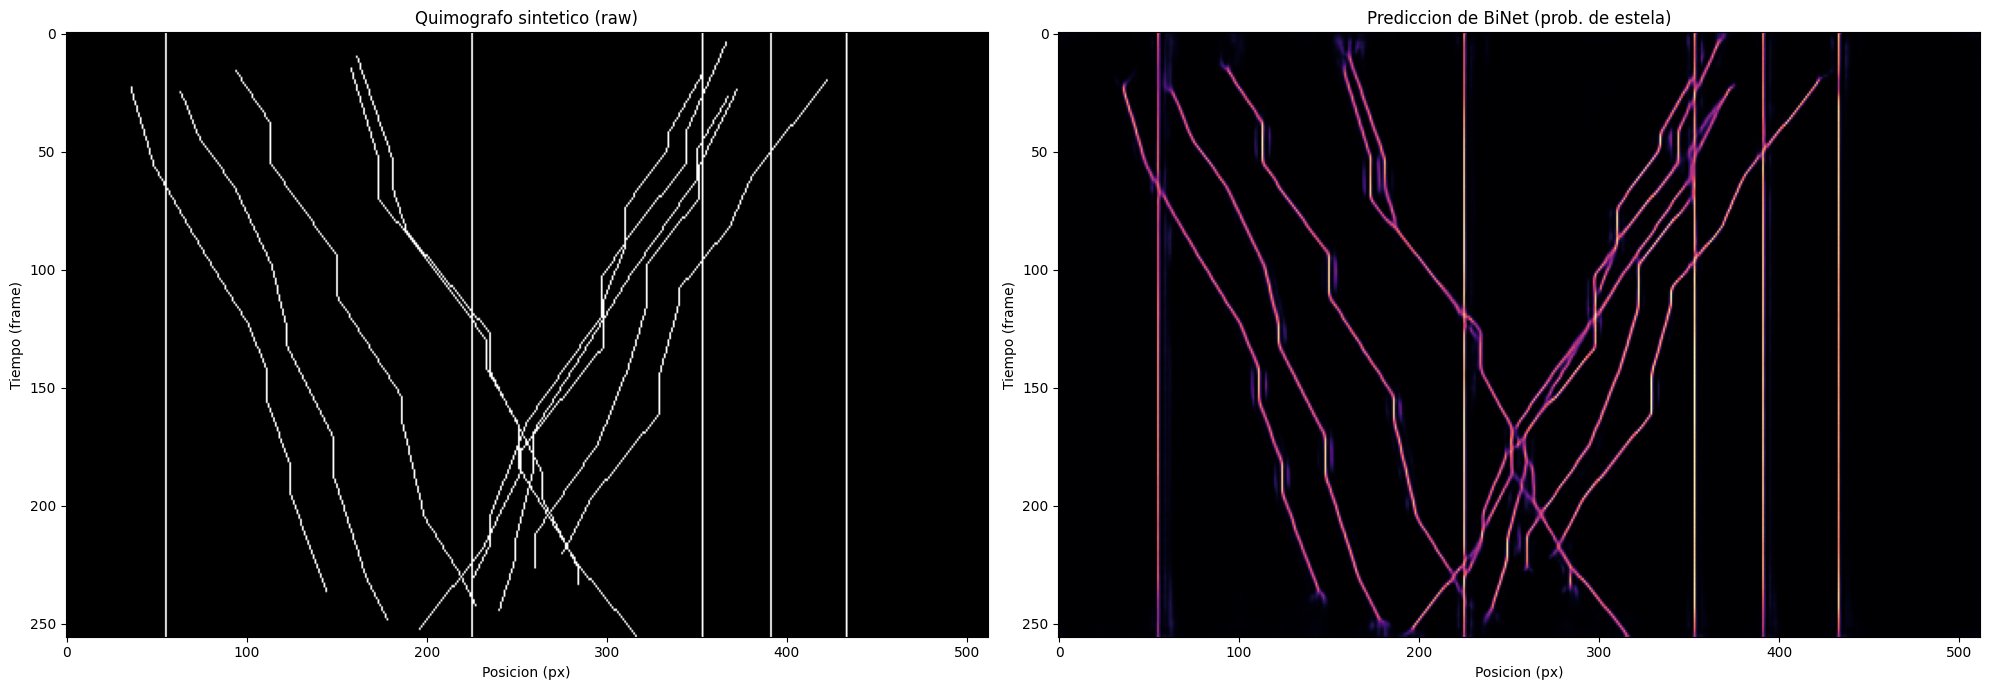

In [4]:
was_negated, raw, preprocessed, prediction = segment_bidirectional(
    str(PNG), models["binet"], device=DEVICE
)
print(f"was_negated={was_negated} (False = fondo negro, correcto)")
print(f"raw {raw.shape}, preprocessed {preprocessed.shape}, prediction {prediction.shape}")
print(f"prediction range=[{prediction.min():.3f}, {prediction.max():.3f}]")

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
axes[0].imshow(raw, cmap="gray", aspect="auto")
axes[0].set_title("Quimografo sintetico (raw)")
axes[1].imshow(prediction, cmap="magma", aspect="auto")
axes[1].set_title("Prediccion de BiNet (prob. de estela)")
for ax in axes:
    ax.set_xlabel("Posicion (px)")
    ax.set_ylabel("Tiempo (frame)")
plt.tight_layout()
plt.show()

---

## 4. Tracking

`track_bidirectional` esqueletiza la segmentación, siembra tracks y los extiende con vecino más cercano, usando **DecNet** para resolver ambigüedades en los cruces. Cada track es una lista de puntos `(t, x)`.

In [5]:
tracks = track_bidirectional(
    prediction, preprocessed, was_negated,
    vision_net=models["decnet"],
    threshold=0.2, min_size=10, min_frames=10, device=DEVICE,
)
print(f"Tracks detectados: {len(tracks)}")
if tracks:
    largos = [len(t.points) for t in tracks]
    print(f"  Puntos por track: min={min(largos)}, mediana={int(np.median(largos))}, max={max(largos)}")

Building tracks:   0%|          | 0/13 [00:00<?, ?it/s]

Building tracks:  23%|██▎       | 3/13 [00:00<00:00, 23.13it/s]

Building tracks:  46%|████▌     | 6/13 [00:00<00:00, 26.43it/s]

Building tracks:  77%|███████▋  | 10/13 [00:00<00:00, 30.89it/s]

Tracks detectados: 19
  Puntos por track: min=13, mediana=197, max=248


### Overlay de los tracks

Coloreamos por dirección inferida por KymoButler: **magenta** = anterógrado (columna crece), **cyan** = retrógrado (columna decrece), **amarillo** = sin desplazamiento neto.

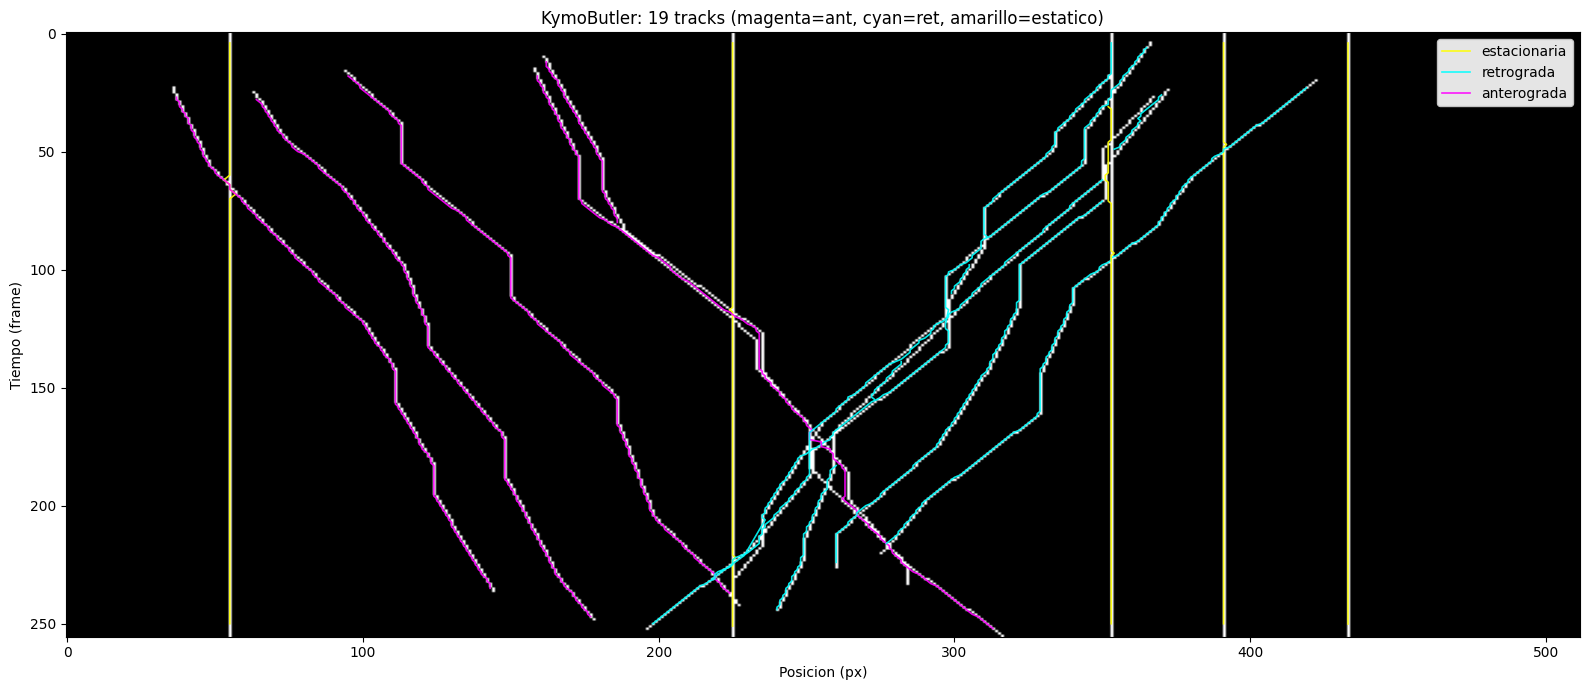

In [6]:
def direccion_pred(trk):
    d = trk.points[-1][1] - trk.points[0][1]
    return "anterograda" if d > 1 else "retrograda" if d < -1 else "estacionaria"

COLORES = {"anterograda": "magenta", "retrograda": "cyan", "estacionaria": "yellow"}

fig, ax = plt.subplots(figsize=(16, 7))
ax.imshow(raw, cmap="gray", aspect="auto")
vistos = set()
for trk in tracks:
    d = direccion_pred(trk)
    pts = np.array(trk.points)  # (N, 2) = (t, x)
    etiqueta = d if d not in vistos else None
    vistos.add(d)
    ax.plot(pts[:, 1], pts[:, 0], color=COLORES[d], linewidth=1.2, alpha=0.9, label=etiqueta)
ax.set_title(f"KymoButler: {len(tracks)} tracks (magenta=ant, cyan=ret, amarillo=estatico)")
ax.set_xlabel("Posicion (px)")
ax.set_ylabel("Tiempo (frame)")
ax.legend(loc="upper right", framealpha=0.9)
plt.tight_layout()
plt.show()

---

## 5. Cinética (postprocesamiento de KymoButler)

`postprocess` calcula dirección, velocidad, distancia y duración por track. Atención: en datos **sintéticos** el eje temporal está en *frames* (no hay framerate físico), así que usamos `pixel_size_time=1.0` y las "velocidades" quedan en **µm/frame** (espacial sí: `PIXEL_SIZE_UM`).

In [7]:
from kymobutler.postprocessing import postprocess

stats = postprocess(tracks, pixel_size_time=1.0, pixel_size_space=PIXEL_SIZE_UM)
df_cin = pd.DataFrame(stats).rename(columns={
    "velocity_um_per_sec": "velocidad_um_frame",
    "duration_sec": "duracion_frames",
    "distance_um": "distancia_um",
    "start2end_velocity_um_per_sec": "vel_neta_um_frame",
})
print("Tracks por direccion (signo del desplazamiento):")
print(f"  anterograda (+1): {(df_cin.direction == 1).sum()}")
print(f"  retrograda  (-1): {(df_cin.direction == -1).sum()}")
print(f"  estatica    ( 0): {(df_cin.direction == 0).sum()}")
print()
print(df_cin.describe().round(3))

Tracks por direccion (signo del desplazamiento):
  anterograda (+1): 6
  retrograda  (-1): 9
  estatica    ( 0): 4

       direction  velocidad_um_frame  duracion_frames  distancia_um  \
count     19.000              19.000           19.000        19.000   
mean      -0.158               0.077          164.421         6.685   
std        0.898               0.016           88.085         6.661   
min       -1.000               0.054           13.000         0.000   
25%       -1.000               0.063           76.000         0.802   
50%        0.000               0.083          209.000         2.568   
75%        1.000               0.090          230.500        12.947   
max        1.000               0.096          248.000        16.906   

       vel_neta_um_frame  
count             19.000  
mean               0.046  
std                0.030  
min                0.000  
25%                0.019  
50%                0.055  
75%                0.071  
max                0.086  


---

## 6. Comparación contra el ground truth

Acá está el valor del sintético. Para cada track predicho asociamos cada punto `(t, x)` a la partícula GT más cercana en ese frame (tolerancia `THR_PX`). Con eso medimos:

- **Recall**: qué fracción de las partículas GT fue recuperada (global y por tipo).
- **Error de posición**: |x_predicho − x_GT| promedio (px y µm).
- **Acierto de dirección**: dirección inferida vs. etiqueta GT.
- **Cruces**: un track que sigue de forma **sustancial** (≥ `MIN_OVERLAP` frames) a **más de una** partícula GT es un **ID-switch** (la falla clásica en los X-junctions). El umbral de solapamiento evita falsos positivos: cerca de un cruce, los puntos de un track quedan momentáneamente más cerca de la línea que lo cruza, pero eso no es un cambio de identidad. Una partícula GT cubierta por **varios** tracks está **fragmentada**.

In [8]:
from collections import Counter

THR_PX = 4.0       # tolerancia de asociacion predicho <-> GT (px)
MIN_OVERLAP = 10   # frames minimos para considerar que un track "pertenece" a una particula GT

gt = pd.read_csv(GT_CSV)
tipo_de = dict(zip(gt.particula_id, gt.tipo))
gt_ids = sorted(gt.particula_id.unique())
gt_dir = {pid: (1 if tipo_de[pid] == "anterograda"
                else -1 if tipo_de[pid] == "retrograda" else 0) for pid in gt_ids}
gt_x = {(int(r.particula_id), int(r.frame)): float(r.x_px) for r in gt.itertuples()}
gt_por_frame = {int(f): list(zip(s.particula_id, s.x_px))
                for f, s in gt.groupby("frame")}

def gt_mas_cercano(t, x):
    mejor, dmin = -1, THR_PX
    for pid, gx in gt_por_frame.get(int(t), []):
        d = abs(x - gx)
        if d <= dmin:
            mejor, dmin = int(pid), d
    return mejor

filas = []
for k, trk in enumerate(tracks):
    etiquetas = [gt_mas_cercano(t, x) for (t, x) in trk.points]
    conteo = Counter(l for l in etiquetas if l != -1)
    # Particulas GT que el track sigue de forma sustancial (>= MIN_OVERLAP frames).
    sustanciales = {pid: c for pid, c in conteo.items() if c >= MIN_OVERLAP}
    if sustanciales:
        dominante = max(sustanciales, key=sustanciales.get)
    elif conteo:
        dominante = conteo.most_common(1)[0][0]
    else:
        dominante = -1
    errs = [abs(x - gt_x[(dominante, int(t))])
            for (t, x), l in zip(trk.points, etiquetas)
            if l == dominante and dominante != -1 and (dominante, int(t)) in gt_x]
    dpred = trk.points[-1][1] - trk.points[0][1]
    dir_pred = int(np.sign(dpred)) if abs(dpred) > 1 else 0
    filas.append({
        "track": k,
        "gt_id": dominante,
        "gt_tipo": tipo_de.get(dominante, "-"),
        "n_puntos": len(trk.points),
        "id_switch": len(sustanciales) > 1,
        "dir_pred": dir_pred,
        "dir_gt": gt_dir.get(dominante, None),
        "dir_ok": (dir_pred == gt_dir.get(dominante)) if dominante != -1 else False,
        "err_px": float(np.mean(errs)) if errs else np.nan,
    })

comp = pd.DataFrame(filas)
print(comp.to_string(index=False))

 track  gt_id      gt_tipo  n_puntos  id_switch  dir_pred  dir_gt  dir_ok   err_px
     0      4 estacionaria       247      False         0       0    True 0.387318
     1      1 estacionaria       248      False         0       0    True 0.244828
     2     14   retrograda        83       True        -1      -1    True 0.338886
     3      0 estacionaria       247      False         0       0    True 0.111429
     4      2 estacionaria       247      False         0       0    True 0.005970
     5     10   retrograda       197       True        -1      -1    True 0.451482
     6      6  anterograda        69      False         1       1    True 0.437775
     7      7  anterograda       220      False         1       1    True 0.352065
     8      5  anterograda       235       True         1       1    True 0.422323
     9     12   retrograda       194      False        -1      -1    True 0.306660
    10     13   retrograda        24      False        -1      -1    True 0.895232
    

### Métricas agregadas

In [9]:
asociados = comp[comp.gt_id != -1]
recuperadas = set(asociados.gt_id)

print("=== DETECCION (recall) ===")
print(f"  Global: {len(recuperadas)}/{len(gt_ids)} = {100*len(recuperadas)/len(gt_ids):.0f}%")
for tipo in ("estacionaria", "anterograda", "retrograda"):
    ids_tipo = [p for p in gt_ids if tipo_de[p] == tipo]
    rec = len([p for p in ids_tipo if p in recuperadas])
    print(f"  {tipo:13s}: {rec}/{len(ids_tipo)}")

print("\n=== POSICION ===")
err_validos = asociados.err_px.dropna()
if len(err_validos):
    print(f"  Error medio: {err_validos.mean():.2f} px = {err_validos.mean()*PIXEL_SIZE_UM:.3f} um")
    print(f"  Error mediano: {err_validos.median():.2f} px")

print("\n=== DIRECCION ===")
if len(asociados):
    print(f"  Acierto: {100*asociados.dir_ok.mean():.0f}% ({asociados.dir_ok.sum()}/{len(asociados)} tracks asociados)")

print("\n=== CRUCES ===")
n_idswitch = int(comp.id_switch.sum())
frag = Counter(asociados.gt_id)
n_frag = sum(1 for pid, c in frag.items() if c > 1)
print(f"  ID-switches (track sobre >1 particula GT): {n_idswitch}/{len(tracks)} tracks")
print(f"  Particulas GT fragmentadas (>1 track):     {n_frag}/{len(recuperadas)} recuperadas")
n_sin_asociar = int((comp.gt_id == -1).sum())
print(f"  Tracks sin asociar a ningun GT (falsos +):  {n_sin_asociar}")

=== DETECCION (recall) ===
  Global: 15/15 = 100%
  estacionaria : 5/5
  anterograda  : 5/5
  retrograda   : 5/5

=== POSICION ===
  Error medio: 0.40 px = 0.043 um
  Error mediano: 0.39 px

=== DIRECCION ===
  Acierto: 100% (19/19 tracks asociados)

=== CRUCES ===
  ID-switches (track sobre >1 particula GT): 4/19 tracks
  Particulas GT fragmentadas (>1 track):     3/15 recuperadas
  Tracks sin asociar a ningun GT (falsos +):  0


### GT vs predicho (superpuestos)

Líneas finas = ground truth (por tipo). Cruces rojas = ID-switches detectados (donde un track mezcla identidades en un cruce).

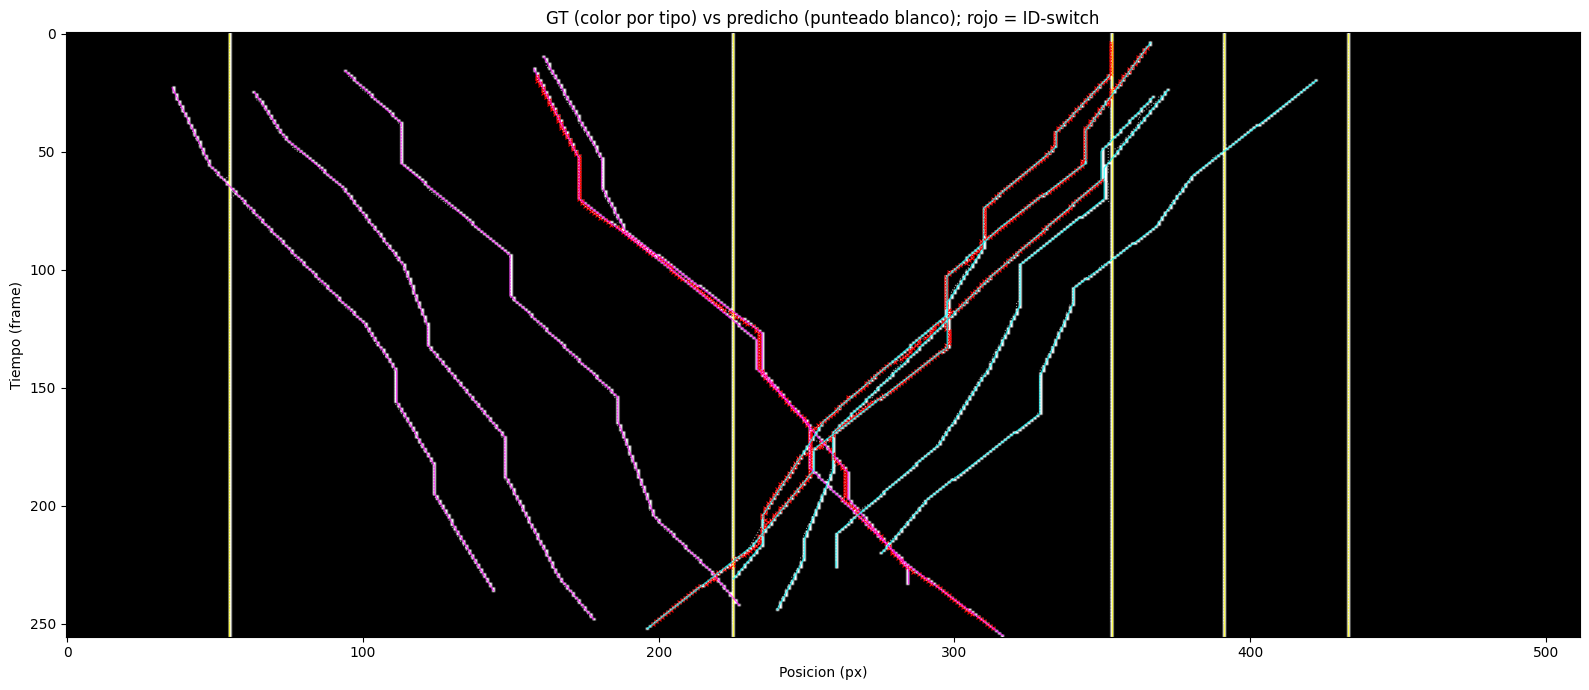

In [10]:
fig, ax = plt.subplots(figsize=(16, 7))
ax.imshow(raw, cmap="gray", aspect="auto")

# Ground truth (lineas finas continuas).
T = raw.shape[0]
for pid in gt_ids:
    sub = gt[gt.particula_id == pid].sort_values("frame")
    ax.plot(sub.x_px, sub.frame, color=COLORES[tipo_de[pid]], linewidth=1.0, alpha=0.7)

# Predicho (punteado blanco) + marca de ID-switch.
for k, trk in enumerate(tracks):
    pts = np.array(trk.points)
    ax.plot(pts[:, 1], pts[:, 0], color="white", linewidth=0.8, alpha=0.6, linestyle=":")
    if comp.iloc[k]["id_switch"]:
        ax.scatter(pts[:, 1], pts[:, 0], c="red", s=8, marker="x", linewidths=0.8)

ax.set_title("GT (color por tipo) vs predicho (punteado blanco); rojo = ID-switch")
ax.set_xlabel("Posicion (px)")
ax.set_ylabel("Tiempo (frame)")
plt.tight_layout()
plt.show()

---

## Conclusión

Este notebook midió a **KymoButler** sobre el quimógrafo sintético **ideal (nivel 1)** contra el ground truth exacto, reportando recall, error de posición, acierto de dirección y comportamiento en cruces.

### Lectura de los resultados

- En el caso ideal (sin ruido), el recall y el error de posición indican el **piso de desempeño** del baseline aprendido.
- Los **ID-switches** y la **fragmentación** en los cruces son la métrica clave: ahí es donde un modelo con atención global (transformers) debería mejorar.

### Próximos pasos

1. **Nivel 2**: regenerar el sintético con `ruido` y `sigma_psf` (notebook 04) y repetir, viendo cómo cae el desempeño.
2. Probar `track_unidirectional` / `segment_unidirectional` si conviene separar anterógrado/retrógrado explícitamente.
3. Pasar a quimógrafos **reales** anotados y comparar.
4. Reutilizar estas métricas (recall, error, dirección, ID-switch) como tabla común para comparar KymoButler vs. los modelos basados en transformers.